# Part 3 - ParTime Series Analysis with Machine Learning and Prophet


In this tutorial, we will forecast monthly airline passenger numbers using two approaches:

1. **Prophet**, a forecasting library designed for trend and seasonality.
2. **Machine learning**, using manually engineered time-series features.

We will use the real `flights` dataset from Seaborn. It contains monthly airline passenger counts from 1949 to 1960.


## Introduction to Prophet

**Prophet** is an open-source forecasting library developed by Meta (formerly Facebook) and released in 2017. It is designed to make time series forecasting accessible to analysts and data scientists who may not have deep expertise in time series modeling.

### What makes Prophet different?

Most classical forecasting methods (like ARIMA) require the user to manually identify the model order, handle stationarity, and tune parameters carefully. Prophet takes a different approach:

- It fits an **additive regression model** with interpretable components: trend, seasonality, and holidays.
- It is designed to handle **missing data**, **outliers**, and **irregular time series** gracefully.
- It requires minimal configuration and works well out of the box on many real-world datasets.

### How Prophet works

Prophet decomposes a time series into three main components:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

| Component | Description |
|-----------|-------------|
| $g(t)$ | **Trend** — models non-periodic changes (linear or logistic growth) |
| $s(t)$ | **Seasonality** — models periodic patterns (yearly, weekly, daily) using Fourier series |
| $h(t)$ | **Holidays** — models the effect of user-specified special events |
| $\epsilon_t$ | **Error** — captures any remaining unexplained variation |

### When to use Prophet

Prophet works best when:

- The time series has at least a few months of historical data.
- There are clear seasonal patterns (e.g., yearly cycles).
- The data may contain missing values or occasional outliers.
- You need a fast, interpretable baseline forecast without extensive manual tuning.

### Input format

Prophet requires a DataFrame with exactly two columns:

- `ds` — the datestamp column (datetime format)
- `y` — the numeric value to forecast

This tutorial uses the classic airline passengers dataset to demonstrate both Prophet and a machine learning alternative.

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">0. Install Required Libraries</h3>
</div>

Run this cell only if the required libraries are not already installed in your environment.

`prophet` can sometimes take a little longer to install because it depends on forecasting-related backend packages.

In [1]:
# Uncomment and run if needed:
# !pip install prophet seaborn scikit-learn matplotlib pandas

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">1. Import Libraries</h3>
</div>

We import libraries for:

- data manipulation
- visualization
- forecasting with Prophet
- machine learning with Random Forest
- model evaluation using MAE and RMSE

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from prophet import Prophet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

Importing plotly failed. Interactive plots will not work.


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">2. Load the Dataset</h3>
</div>

The `flights` dataset (from Seaborn) contains monthly airline passenger counts and is a classic benchmark for time-series forecasting.

Why this dataset is useful:

- It spans **1949 to 1960** (12 years).
- It has **144 monthly observations** (12 months × 12 years).
- It shows a clear long-term upward trend in passenger volume.
- It also has repeating yearly seasonality (similar patterns across months each year).

The original columns are:

- `year`
- `month`
- `passengers`

Prophet requires two specific column names:

- `ds`: the date column
- `y`: the target value we want to forecast

So we convert the original dataset into Prophet's expected format by building a proper monthly datetime column and renaming `passengers` to `y`.

In [3]:
df = sns.load_dataset("flights")

df["ds"] = pd.to_datetime(
    df["year"].astype(str) + "-" + df["month"].astype(str) + "-01"
)

df = df[["ds", "passengers"]].rename(columns={"passengers": "y"})

df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">3. Visualize the Time Series</h3>
</div>

Before building a model, always plot the data.

This helps us identify:

- the overall trend
- yearly seasonality
- unusual observations
- whether the series is increasing, decreasing, or stable

This dataset clearly shows an upward trend and seasonal fluctuations.

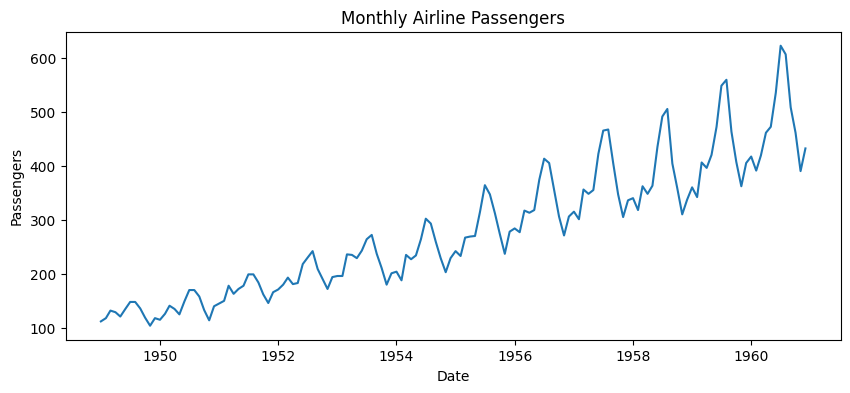

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(df["ds"], df["y"])
plt.title("Monthly Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.show()

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">4. Split the Data</h3>
</div>

For time series forecasting, we do **not** randomly split the data.

Instead, we train on older observations and test on future observations.

Here, we use:

- all data except the final 12 months for training
- the final 12 months for testing

This simulates a realistic forecasting situation.

In [5]:
train = df.iloc[:-12]
test = df.iloc[-12:]

print("Training data shape:", train.shape)
print("Testing data shape:", test.shape)

Training data shape: (132, 2)
Testing data shape: (12, 2)


<div style="
    background-color:#8F0177;
    padding:20px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h2 style="margin:0;">Forecasting with Prophet</h2>
</div>

Prophet is designed for time series that contain trend and seasonality.

It is commonly used when we want a fast forecasting baseline with interpretable components.

Our data is monthly, so we enable yearly seasonality and disable weekly and daily seasonality.

In [6]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

07:47:27 - cmdstanpy - INFO - Chain [1] start processing


07:47:27 - cmdstanpy - INFO - Chain [1] done processing


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">5. Create Future Dates</h3>
</div>

Prophet does not automatically know how far into the future we want to forecast.

We use `make_future_dataframe()` to create future dates.

Because the dataset is monthly, we use `freq="MS"`, which means month start frequency.

We add 12 future months because our test set contains 12 months.

In [7]:
future = model.make_future_dataframe(periods=12, freq="MS")

future.tail()

,ds
139,1960-08-01
140,1960-09-01
141,1960-10-01
142,1960-11-01
143,1960-12-01


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">6. Generate the Forecast</h3>
</div>

The `predict()` method generates the forecast.

The most important forecast columns are:

- `ds`: the date
- `yhat`: the predicted value
- `yhat_lower`: the lower uncertainty estimate
- `yhat_upper`: the upper uncertainty estimate

We display the final 12 rows because those correspond to the forecast period.

In [8]:
forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12)

,ds,yhat,yhat_lower,yhat_upper
132,1960-01-01,424.881294,398.273946,449.004960
133,1960-02-01,421.489428,395.438236,448.735402
134,1960-03-01,457.002985,430.093114,483.605424
135,1960-04-01,451.393875,426.939240,477.681063
136,1960-05-01,453.900819,427.095308,480.392100
137,1960-06-01,493.715546,467.882572,518.963957
138,1960-07-01,523.845021,497.925253,548.503566
139,1960-08-01,527.280362,501.299630,552.231085
140,1960-09-01,486.059030,460.201500,512.447396
141,1960-10-01,452.372616,427.007757,476.058015


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">7. Evaluate Prophet</h3>
</div>

We compare the Prophet forecast against the actual values in the test set.

We use two common metrics:

- **MAE**: Mean Absolute Error. Lower is better.
- **RMSE**: Root Mean Squared Error. Lower is better, and large errors are penalized more strongly.

In [9]:
prophet_pred = forecast.iloc[-12:]["yhat"]

prophet_mae = mean_absolute_error(test["y"], prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test["y"], prophet_pred))

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 33.434522332343725
Prophet RMSE: 43.067854056122655


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">8. Plot the Prophet Forecast</h3>
</div>

This plot shows:

- the historical data
- the forecasted future values
- the uncertainty interval around the forecast

The uncertainty interval gives a range of plausible future values, not a guaranteed boundary.

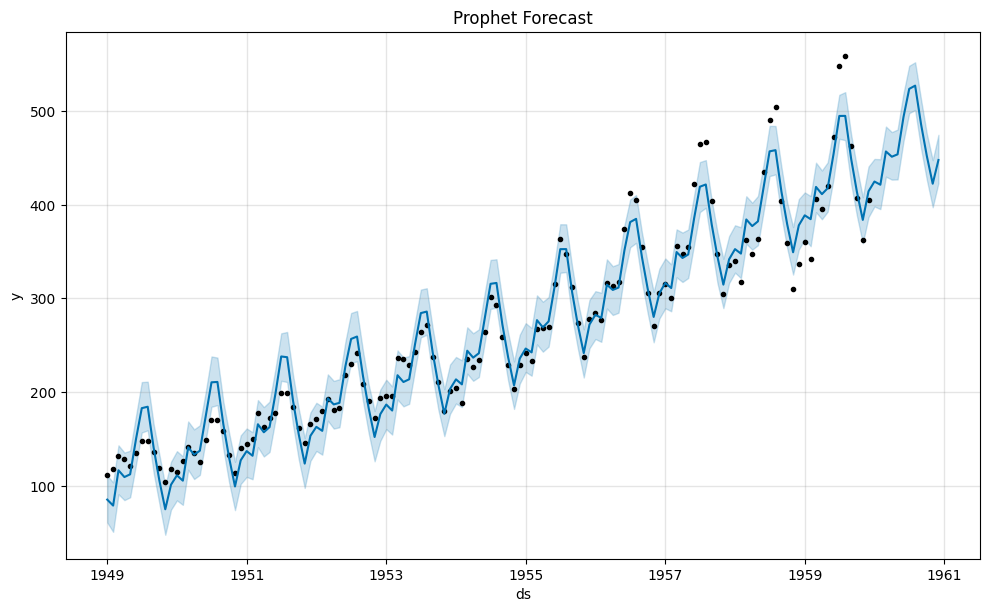

In [10]:
fig = model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">9. Plot Prophet Components</h3>
</div>

Prophet decomposes the forecast into components.

For this dataset, the most useful components are:

- trend
- yearly seasonality

This makes Prophet more interpretable than many black-box machine learning models.

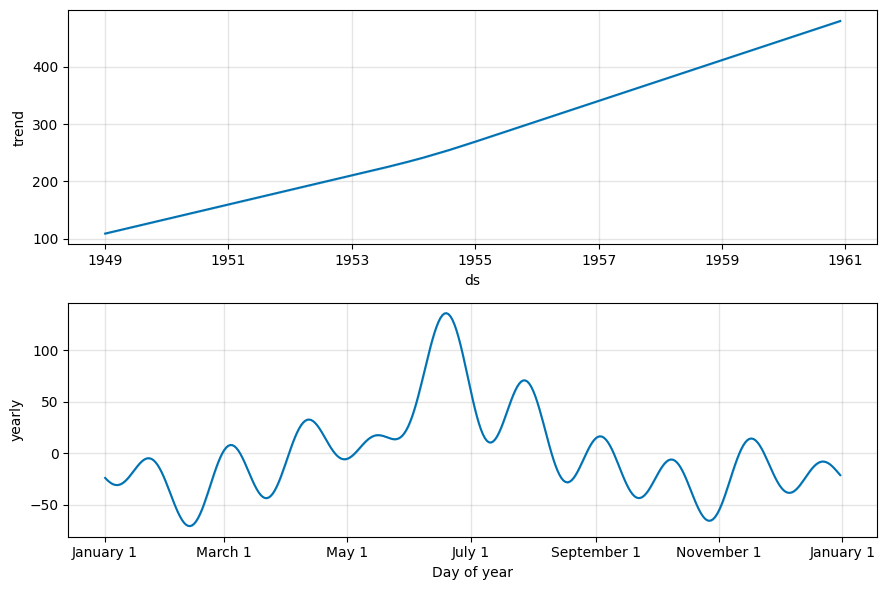

In [11]:
fig = model.plot_components(forecast)
plt.show()

<div style="
    background-color:#8F0177;
    padding:20px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h2 style="margin:0;">Part 2: Machine Learning for Time Series</h2>
</div>

Most machine learning models do not understand time automatically.

We must convert the time series into a supervised learning problem by creating useful features.

Examples of time-series features include:

- month
- year
- time index
- previous values
- rolling averages

This process is called **feature engineering**.

In [12]:
ml_df = df.copy()

ml_df["month"] = ml_df["ds"].dt.month
ml_df["year"] = ml_df["ds"].dt.year
ml_df["time_index"] = range(len(ml_df))

ml_df["lag_1"] = ml_df["y"].shift(1)
ml_df["lag_12"] = ml_df["y"].shift(12)
ml_df["rolling_3"] = ml_df["y"].shift(1).rolling(3).mean()

ml_df = ml_df.dropna()

ml_df.head()

,ds,y,month,year,time_index,lag_1,lag_12,rolling_3
12,1950-01-01,115,1,1950,12,118.0,112.0,113.666667
13,1950-02-01,126,2,1950,13,115.0,118.0,112.333333
14,1950-03-01,141,3,1950,14,126.0,132.0,119.666667
15,1950-04-01,135,4,1950,15,141.0,129.0,127.333333
16,1950-05-01,125,5,1950,16,135.0,121.0,134.000000


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">10. Understand the Engineered Features</h3>
</div>

The new features are:

- `month`: captures yearly seasonality
- `year`: captures long-term growth
- `time_index`: captures the passage of time as a numeric feature
- `lag_1`: the passenger count from the previous month
- `lag_12`: the passenger count from the same month last year
- `rolling_3`: the average passenger count over the previous 3 months

Notice that we use `.shift(1)` before rolling.

This prevents **data leakage**, because the model should not use the current month's value to predict the current month.

In [13]:
features = ["month", "year", "time_index", "lag_1", "lag_12", "rolling_3"]

features

['month', 'year', 'time_index', 'lag_1', 'lag_12', 'rolling_3']

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">11. Split the Machine Learning Data</h3>
</div>

After creating lag features, the first rows contain missing values and were removed.

We again use the final 12 rows as the test set.

This keeps the comparison with Prophet fair.

In [14]:
train_ml = ml_df.iloc[:-12]
test_ml = ml_df.iloc[-12:]

X_train = train_ml[features]
y_train = train_ml["y"]

X_test = test_ml[features]
y_test = test_ml["y"]

print("ML training data shape:", X_train.shape)
print("ML testing data shape:", X_test.shape)

ML training data shape: (120, 6)
ML testing data shape: (12, 6)


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">12. Train a Random Forest Model</h3>
</div>

Random Forest is a general-purpose machine learning model.

It can learn nonlinear relationships, but it does not naturally understand time.

That is why our lag and calendar features are important.

In [15]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">13. Predict Using the Random Forest Model</h3>
</div>

Now we use the trained Random Forest model to predict the final 12 months.

These predictions will be compared with both the real values and the Prophet predictions.

In [16]:
rf_pred = rf.predict(X_test)

rf_pred

array([414.47      , 393.17      , 454.79333333, 441.51333333,
       473.74666667, 521.69666667, 546.14666667, 546.86      ,
       520.11666667, 468.07333333, 422.82      , 456.61      ])

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">14. Evaluate the Random Forest Model</h3>
</div>

We calculate the same metrics used for Prophet.

Using the same metrics makes the comparison fair and easy to interpret.

In [17]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 23.886944444444442
Random Forest RMSE: 32.89243852372513


<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">15. Compare Both Models Visually</h3>
</div>

Finally, we plot:

- the actual values
- Prophet predictions
- Random Forest predictions

Visual comparison is important because metrics alone do not show whether the model captures the overall pattern of the time series.

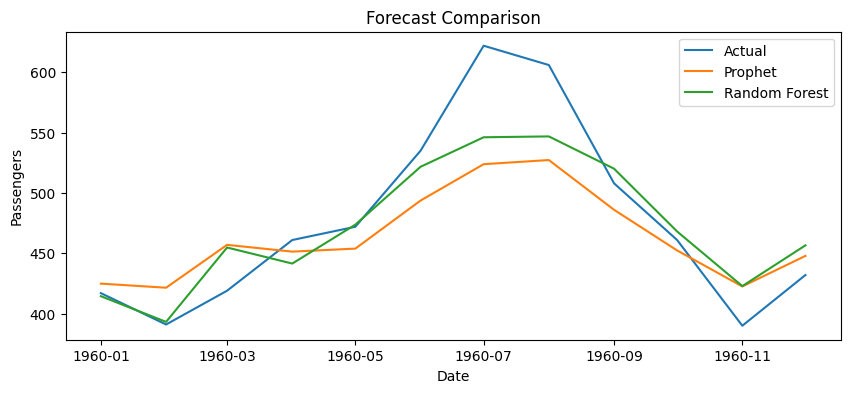

In [18]:
plt.figure(figsize=(10, 4))

plt.plot(test["ds"], test["y"], label="Actual")
plt.plot(test["ds"], prophet_pred, label="Prophet")
plt.plot(test_ml["ds"], rf_pred, label="Random Forest")

plt.title("Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

<div style="
    background-color:#8F0177;
    padding:15px;
    border-radius:8px;
    color:white;
    display:flex;
    align-items:center;
">
    <h3 style="margin:0;">Summary</h3>
</div>

In this tutorial, we used two forecasting approaches.

**Prophet** is simple and useful when the time series has clear trend and seasonality.

**Machine learning models** can also forecast time series, but they need carefully designed features.

Important lessons:

- Do not randomly split time-series data.
- Train on the past and test on the future.
- Prophet expects columns named `ds` and `y`.
- ML models need lag features, rolling features, and date features.
- Always evaluate forecasts using future data.